In [7]:
import numpy as np
from matplotlib.pyplot import subplots, cm
import sklearn.model_selection as skm
from ISLP import load_data, confusion_table
from sklearn.svm import SVC

from ISLP.svm import plot as plot_svm
from sklearn.metrics import RocCurveDisplay

roc_curve = RocCurveDisplay.from_estimator #

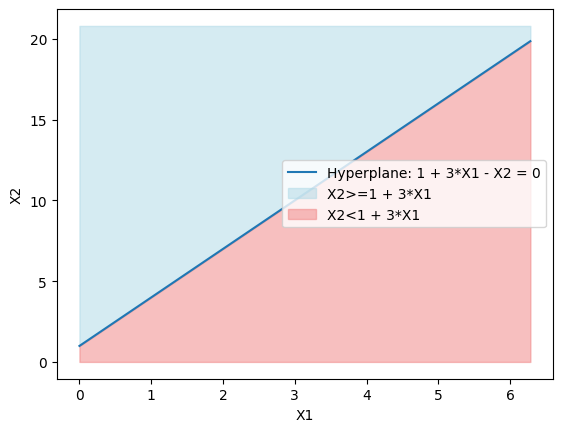

In [30]:
# plot the line 1 + 3*X1 - X2 = 0  ->  X2 = -1 - 3*X1
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
x2_line = 1 + 3 * x1
ax.plot(x1, x2_line, label='Hyperplane: 1 + 3*X1 - X2 = 0')
ax.fill_between(x1, x2_line, y2=ax.get_ylim()[1], color='lightblue', alpha=0.5, label='X2>=1 + 3*X1')
ax.fill_between(x1, x2_line, y2=ax.get_ylim()[0], color='lightcoral', alpha=0.5, label='X2<1 + 3*X1')
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.legend()

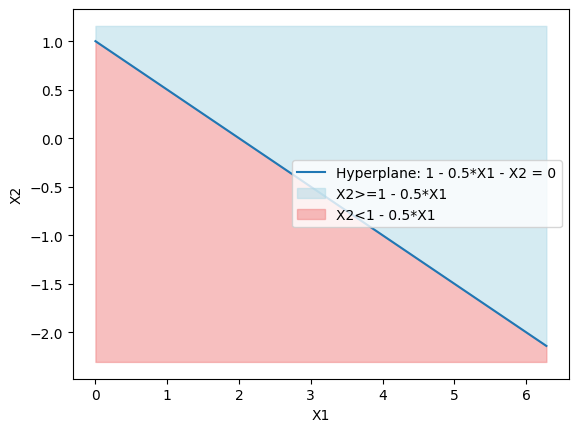

In [31]:
fig, ax = plt.subplots()
x2_line = 1 - 0.5 * x1
ax.plot(x1, x2_line, label='Hyperplane: 1 - 0.5*X1 - X2 = 0')
ax.fill_between(x1, x2_line, y2=ax.get_ylim()[1], color='lightblue', alpha=0.5, label='X2>=1 - 0.5*X1')
ax.fill_between(x1, x2_line, y2=ax.get_ylim()[0], color='lightcoral', alpha=0.5, label='X2<1 - 0.5*X1')
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.legend()

In [66]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score



Text(0, 0.5, 'X2')

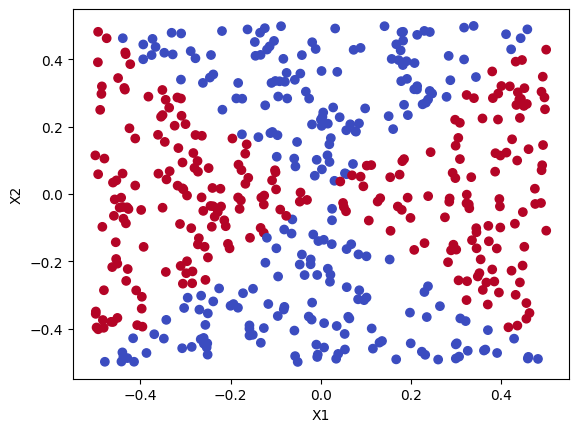

In [ ]:
rng = np.random.default_rng(5)
x1 = rng.uniform(size=500) - 0.5
x2 = rng.uniform(size=500) - 0.5
y = x1**2 - x2**2 > 0
# Plot the generated 500 points (use x1 and x2 so lengths match y)
fig, ax = plt.subplots()

ax.scatter(x1, x2, c=y, cmap=cm.coolwarm)
ax.set_xlabel('X1')
ax.set_ylabel('X2')



In [61]:
X = np.column_stack([x1, x2])
y_int = y.astype(int)

In [62]:
traintestsplit = skm.train_test_split(X, y_int, test_size=0.3, random_state=42)
X_train, X_test, y_train, y_test = traintestsplit

In [63]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

clf = LogisticRegression(solver='lbfgs')
clf.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [64]:
intercept = float(clf.intercept_[0])
coef1, coef2 = clf.coef_[0][0], clf.coef_[0][1]
print("Logistic regression (standardized features)")
print("Intercept:", round(intercept, 4))
print("Coef X1:", round(coef1, 4))
print("Coef X2:", round(coef2, 4))

Logistic regression (standardized features)
Intercept: 0.0977
Coef X1: -0.352
Coef X2: -0.0943


In [67]:
y_pred = clf.predict(X_test_s)
acc = accuracy_score(y_test, y_pred)
print("\nTest accuracy:", round(acc, 4))
print("\nClassification report:\n")
print(classification_report(y_test, y_pred, digits=4))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))


Test accuracy: 0.4133

Classification report:

              precision    recall  f1-score   support

           0     0.4407    0.3210    0.3714        81
           1     0.3956    0.5217    0.4500        69

    accuracy                         0.4133       150
   macro avg     0.4181    0.4214    0.4107       150
weighted avg     0.4199    0.4133    0.4076       150

Confusion matrix:
[[26 55]
 [33 36]]


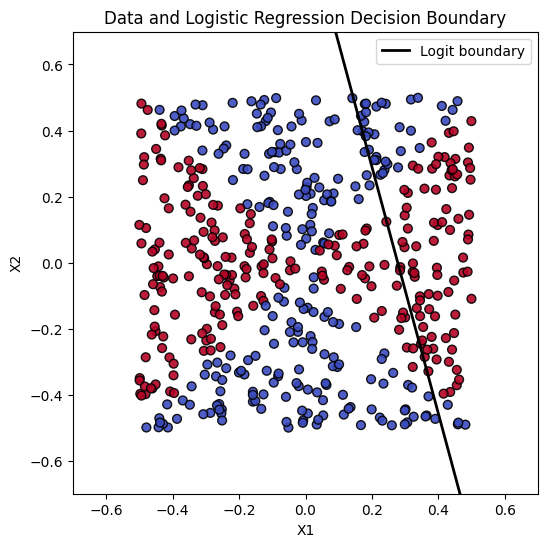

In [69]:
# plot data and logistic regression decision boundary (logit = 0)
fig, ax = plt.subplots(figsize=(6,6))

# scatter the points colored by class
ax.scatter(x1, x2, c=y, cmap=cm.coolwarm, edgecolor='k', s=40, alpha=0.9)
ax.set_xlabel('X1')
ax.set_ylabel('X2')

# compute decision boundary from logit: intercept + coef1*x1 + coef2*x2 = 0
# handle near-zero coef2 (vertical boundary) safely
x_vals = np.linspace(x1.min() - 0.1, x1.max() + 0.1, 200)
if abs(coef2) > 1e-8:
	x2_boundary = -(intercept + coef1 * x_vals) / coef2
	ax.plot(x_vals, x2_boundary, color='black', lw=2, label='Logit boundary')
else:
	# vertical line at x = -intercept/coef1
	x_vert = -intercept / coef1
	ax.axvline(x=x_vert, color='black', lw=2, label='Logit boundary (vertical)')

ax.legend()
ax.set_title('Data and Logistic Regression Decision Boundary')
ax.set_xlim(x1.min() - 0.2, x1.max() + 0.2)
ax.set_ylim(x2.min() - 0.2, x2.max() + 0.2)
plt.show()

In [71]:
# Fit a logistic regression using nonlinear (polynomial) functions of X1 and X2
from sklearn.preprocessing import PolynomialFeatures

# create 2nd-degree polynomial features (X1, X2, X1^2, X1*X2, X2^2)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# scale the polynomial features (StandardScaler is available from previous cells)
scaler_poly = StandardScaler()
X_train_poly_s = scaler_poly.fit_transform(X_train_poly)
X_test_poly_s = scaler_poly.transform(X_test_poly)

# fit logistic regression on the transformed features
clf_poly = LogisticRegression(solver='lbfgs', max_iter=1000)
clf_poly.fit(X_train_poly_s, y_train)

# show feature names and coefficients
try:
	feature_names = poly.get_feature_names_out(['X1', 'X2'])
except AttributeError:
	feature_names = poly.get_feature_names(['X1', 'X2'])  # fallback for older sklearn

print("Polynomial features:", feature_names)
print("Intercept:", float(clf_poly.intercept_[0]))
print("Coefs:", [round(c, 4) for c in clf_poly.coef_[0]])

# evaluate on the test set
y_pred_poly = clf_poly.predict(X_test_poly_s)
print("\nTest accuracy (poly features):", round(accuracy_score(y_test, y_pred_poly), 4))
print("\nClassification report (poly features):\n")
print(classification_report(y_test, y_pred_poly, digits=4))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_poly))

Polynomial features: ['X1' 'X2' 'X1^2' 'X1 X2' 'X2^2']
Intercept: 0.3173132718125805
Coefs: [np.float64(-0.3181), np.float64(-0.2245), np.float64(4.1548), np.float64(-0.0312), np.float64(-4.2873)]

Test accuracy (poly features): 0.9733

Classification report (poly features):

              precision    recall  f1-score   support

           0     1.0000    0.9506    0.9747        81
           1     0.9452    1.0000    0.9718        69

    accuracy                         0.9733       150
   macro avg     0.9726    0.9753    0.9733       150
weighted avg     0.9748    0.9733    0.9734       150

Confusion matrix:
[[77  4]
 [ 0 69]]


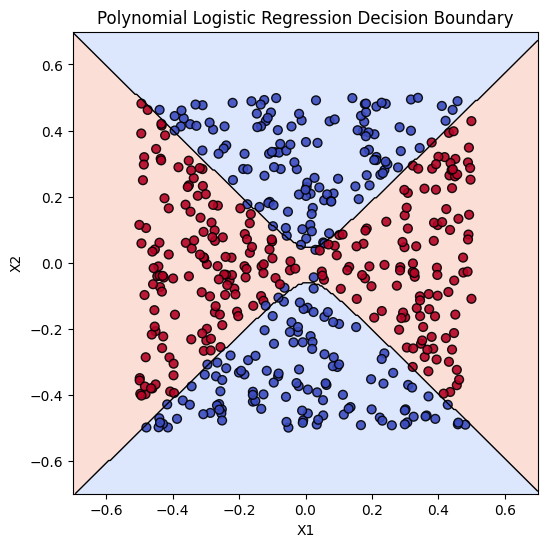

In [72]:
# Plot polynomial logistic regression decision regions in the original X1-X2 space.
# We create a fine grid, transform with the same polynomial transformer and scaler,
# then predict with clf_poly and plot the decision regions plus the data points.

xx, yy = np.meshgrid(
	np.linspace(x1.min() - 0.2, x1.max() + 0.2, 300),
	np.linspace(x2.min() - 0.2, x2.max() + 0.2, 300),
)
grid = np.column_stack([xx.ravel(), yy.ravel()])

# transform grid points to polynomial features and scale
grid_poly = poly.transform(grid)
grid_poly_s = scaler_poly.transform(grid_poly)

# predict and reshape to grid
Z = clf_poly.predict(grid_poly_s).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(6, 6))
ax.contourf(xx, yy, Z, levels=[-0.5, 0.5, 1.5], alpha=0.3, cmap=cm.coolwarm)
ax.contour(xx, yy, Z, levels=[0.5], colors='k', linewidths=1)  # boundary line
ax.scatter(x1, x2, c=y, cmap=cm.coolwarm, edgecolor='k', s=40, alpha=0.9)
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_title('Polynomial Logistic Regression Decision Boundary')
plt.show()

In [77]:
svc_linear = SVC(kernel='linear', C=3.0)
svc_linear.fit(X_train, y_train)

,C,3.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [86]:
# Report results for svc_linear
y_pred_svc = svc_linear.predict(X_test)

acc_svc = accuracy_score(y_test, y_pred_svc)
print("SVC (linear) results")
print("Test accuracy:", round(acc_svc, 4))
print("\nClassification report:\n")
print(classification_report(y_test, y_pred_svc, digits=4))
print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred_svc))



SVC (linear) results
Test accuracy: 0.46

Classification report:

              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000        81
           1     0.4600    1.0000    0.6301        69

    accuracy                         0.4600       150
   macro avg     0.2300    0.5000    0.3151       150
weighted avg     0.2116    0.4600    0.2899       150


Confusion matrix:
[[ 0 81]
 [ 0 69]]


c:\Users\Owen Hirsch\anaconda3\envs\NewKernel\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Owen Hirsch\anaconda3\envs\NewKernel\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Owen Hirsch\anaconda3\envs\NewKernel\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

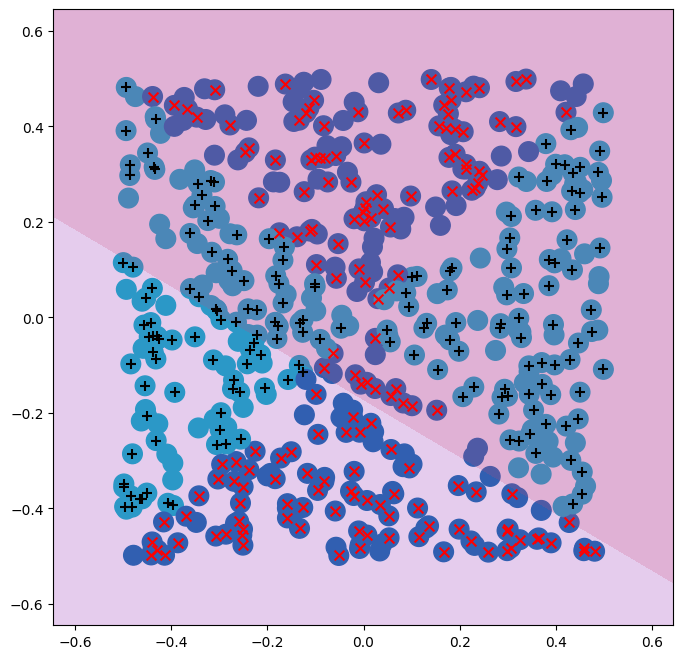

In [79]:
fig, ax = subplots(figsize=(8,8))  # Create a figure and axis with 8x8 inch size

plot_svm(X,
         y,
         svc_linear,
         ax=ax)

In [81]:
svc_non_linear = SVC(kernel='rbf', C=3.0)
svc_non_linear.fit(X_train, y_train)


,C,3.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [87]:
y_pred_svc = svc_non_linear.predict(X_test)

acc_svc = accuracy_score(y_test, y_pred_svc)
print("SVC (non-linear) results")
print("Test accuracy:", round(acc_svc, 4))
print("\nClassification report:\n")
print(classification_report(y_test, y_pred_svc, digits=4))
print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred_svc))

SVC (non-linear) results
Test accuracy: 0.9733

Classification report:

              precision    recall  f1-score   support

           0     1.0000    0.9506    0.9747        81
           1     0.9452    1.0000    0.9718        69

    accuracy                         0.9733       150
   macro avg     0.9726    0.9753    0.9733       150
weighted avg     0.9748    0.9733    0.9734       150


Confusion matrix:
[[77  4]
 [ 0 69]]


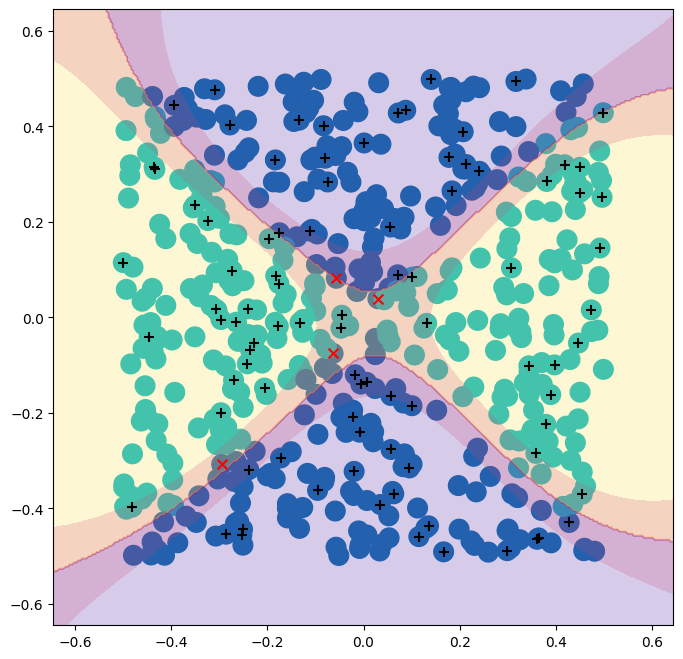

In [82]:
fig, ax = subplots(figsize=(8,8))  # Create a figure and axis with 8x8 inch size

plot_svm(X,
         y,
         svc_non_linear,
         ax=ax)

COMMMENTS:

We can see that obviously the non-linear logit and SVM's did exceedingly better for predicting the non-linear split of the data. We know the functional form of the data and so we can confidently apply hihgly non-linear models.
We should be cautious to apply high polynomial logit or non-linear SVM's to data in other contexts because those models can overfit the training data, and may not acurately capture if the true division is linear. 

The polynomial logistic model and the Non-linear SVM did equally as well. However the polynominal grpahically captured the functional form better and so if we were trying to predict how the models would do as we got further away from the initial clump, I would say the logit is superior due to the SVM tapering in or out near the tails. 

Q 3. Part A

$$
f_m(X) = \frac{e^{Z_m}}{\sum_{\ell=0}^{9} e^{Z_\ell}}
$$

$$
\text{Add } c \text{ to each denominator term: } Z_\ell \mapsto Z_\ell + c \quad (\ell=0,\ldots,9)
$$

$$
\tilde{f}_m(X) = \frac{e^{Z_m}}{\sum_{\ell=0}^{9} e^{Z_\ell + c}}
= \frac{e^{Z_m}}{e^{c}\sum_{\ell=0}^{9} e^{Z_\ell}}
= \frac{1}{e^{c}} \cdot \frac{e^{Z_m}}{\sum_{\ell=0}^{9} e^{Z_\ell}}
= \frac{1}{e^{c}} \, f_m(X)
$$


For the softmax function. If you add c to the ${e^{Z_\ell}}$ resulting in ${e^{Z_\ell +c}}$ the c can be factored out to ${e^{c}}*{e^{Z_\ell}}$ and when suming the ${e^{Z_\ell}}$ the ${e^{c}}$ can be factored out again resulting in the ${e^{Z_m}}/{e^{Z_\ell}}$ being multiple by 1/${e^{c}}$. This doesn't change the ratios of the probabilites. 

The Softmax functions makes decisions based on the higher probability and no matter what the c is the ratios are preserved and the one with the highest probability is still selected. The new probabilites will also sum up to 1/${e^{c}}$ now. Because the probabilites have been scaled by 1/${e^{c}}$. 

Part B

$$
P(Y=k\mid x)=\frac{\exp\!\left(\beta_{k0}+\sum_{j=1}^{p}\beta_{kj}x_j\right)}{\sum_{l=1}^{K}\exp\!\left(\beta_{l0}+\ \sum_{j=1}^{p}\beta_{lj}x_j\right)}
$$

$$
\tilde\beta_{kj}=\beta_{kj}+c_j\quad(j=0,1,\ldots,p)
$$

$$
\tilde\eta_k(x)=\beta_{k0}+\sum_{j=1}^{p}\beta_{kj}x_j+c_0+\sum_{j=1}^{p}c_jx_j
=\eta_k(x)+s(x),\quad s(x)=c_0+\sum_{j=1}^{p}c_jx_j
$$

$$
\tilde P(Y=k\mid x)=\frac{\exp\!\left(\eta_k(x)+s(x)\right)}{\sum_{l=1}^{K}\exp\!\left(\eta_l(x)+s(x)\right)}
=\frac{e^{s(x)}\exp\!\left(\eta_k(x)\right)}{e^{s(x)}\sum_{l=1}^{K}\exp\!\left(\eta_l(x)\right)}
=\frac{\exp\!\left(\eta_k(x)\right)}{\sum_{l=1}^{K}\exp\!\left(\eta_l(x)\right)}
=P(Y=k\mid x)
$$

Only differences in $\eta_k(x)$ effect proababilities. The constant added to all $\beta_{kj}$ is factored out as $e^{s(x)}$ where $s(x)=c_0+\sum_{j=1}^{p}c_jx_j$ (becasue exp(v + u) = exp(v)*exp(u)) and that the $e^{s(x)}$'s from both the numerator and denominator are cancelled out.